<!-- notebook-header -->
# Aprendizado Nao-Supervisionado: Clustering

**Modulo:** 03 - Machine Learning  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** K-Means, DBSCAN, clustering hierarquico, GMM e avaliacao de clusters.


# Aprendizado Nao-Supervisionado: Clustering

## Pre-requisitos e Fio Narrativo

**Pre-requisitos:** 0.2 (distancias e similaridade), 2.2 (normalizacao/limpeza)
**Tempo estimado:** 10 horas
**Objetivo:** Dominar K-Means, DBSCAN, clustering hierarquico e GMM, incluindo como avaliar clusters sem labels.

**Fio narrativo:** Ate agora, todos os modelos tinham labels (classificacao, regressao). Clustering e nosso primeiro encontro com aprendizado **nao-supervisionado**: descobrir estrutura nos dados sem respostas corretas. Isso e fundamental para segmentacao de clientes, deteccao de anomalias, e exploracao de dados. A pergunta muda de "qual a resposta certa?" para "existem grupos naturais?".

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
from copy import deepcopy

# ===== LOAD DATASETS =====
def load_breast_cancer():
    X = np.random.randn(569, 30)
    y = np.random.randint(0, 2, 569)
    feature_names = [f'feature_{i}' for i in range(30)]
    return type('obj', (object,), {'data': X, 'target': y, 'feature_names': feature_names})()

def load_iris():
    X = np.random.randn(150, 4)
    y = np.random.randint(0, 3, 150)
    feature_names = [f'feature_{i}' for i in range(4)]
    return type('obj', (object,), {'data': X, 'target': y, 'feature_names': feature_names})()

def fetch_california_housing():
    X = np.random.randn(20640, 8)
    y = np.random.randn(20640) * 100000
    return type('obj', (object,), {'data': X, 'target': y})()

# ===== CLASSIFICATION MODELS =====
class LogisticRegression:
    def __init__(self, lr=0.01, epochs=100, max_iter=None, random_state=None):
        self.lr = lr
        self.epochs = max_iter if max_iter is not None else epochs
        self.weights = None
        self.bias = None
        self.random_state = random_state
        self.coef_ = None
        self.intercept_ = None
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def fit(self, X, y):
        if self.random_state:
            np.random.seed(self.random_state)
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for _ in range(self.epochs):
            predictions = self.sigmoid(X @ self.weights + self.bias)
            dw = (1/len(X)) * X.T @ (predictions - y)
            db = (1/len(X)) * np.sum(predictions - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
        
        self.coef_ = self.weights
        self.intercept_ = self.bias
        return self
    
    def predict(self, X):
        return (self.sigmoid(X @ self.weights + self.bias) > 0.5).astype(int)
    
    def predict_proba(self, X):
        proba = self.sigmoid(X @ self.weights + self.bias)
        return np.column_stack([1 - proba, proba])
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

class KNeighborsClassifier:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self
    
    def predict(self, X):
        predictions = []
        for x in X:
            distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            k_indices = np.argsort(distances)[:self.n_neighbors]
            k_labels = self.y_train[k_indices]
            prediction = np.bincount(k_labels).argmax()
            predictions.append(prediction)
        return np.array(predictions)
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

class DecisionTreeClassifier:
    def __init__(self, max_depth=5, criterion='gini', random_state=None, min_samples_leaf=1, min_samples_split=2):
        self.max_depth = max_depth
        self.criterion = criterion
        self.random_state = random_state
        self.min_samples_leaf = min_samples_leaf
        self.min_samples_split = min_samples_split
        self.tree = None
        self.feature_importances_ = None
    
    def fit(self, X, y):
        if self.random_state:
            np.random.seed(self.random_state)
        self.tree = self._build_tree(X, y, depth=0)
        self.feature_importances_ = np.ones(X.shape[1]) / X.shape[1]
        return self
    
    def _build_tree(self, X, y, depth):
        n_samples = len(X)
        n_classes = len(np.unique(y))
        
        if n_classes == 1 or depth >= self.max_depth or n_samples < self.min_samples_split:
            return {'leaf': True, 'value': np.bincount(y).argmax() if len(y) > 0 else 0}
        
        best_gain = -1
        best_feature = 0
        best_threshold = 0
        
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] < threshold
                right_mask = ~left_mask
                
                n_left, n_right = np.sum(left_mask), np.sum(right_mask)
                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue
                
                left_entropy = self._entropy(y[left_mask])
                right_entropy = self._entropy(y[right_mask])
                gain = self._entropy(y) - (n_left/len(y) * left_entropy + n_right/len(y) * right_entropy)
                
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        
        left_mask = X[:, best_feature] < best_threshold
        return {
            'leaf': False,
            'feature': best_feature,
            'threshold': best_threshold,
            'left': self._build_tree(X[left_mask], y[left_mask], depth + 1),
            'right': self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        }
    
    def _entropy(self, y):
        if len(y) == 0:
            return 0
        counts = np.bincount(y)
        probs = counts / len(y)
        return -np.sum(probs[probs > 0] * np.log2(probs[probs > 0]))
    
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.tree) for x in X])
    
    def _traverse_tree(self, x, node):
        if node['leaf']:
            return node['value']
        if x[node['feature']] < node['threshold']:
            return self._traverse_tree(x, node['left'])
        return self._traverse_tree(x, node['right'])
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

class RandomForestClassifier:
    def __init__(self, n_estimators=10, max_depth=5, random_state=None, n_jobs=None, min_samples_leaf=1, min_samples_split=2):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.min_samples_leaf = min_samples_leaf
        self.min_samples_split = min_samples_split
        self.trees = []
        self.feature_importances_ = None
    
    def fit(self, X, y):
        if self.random_state:
            np.random.seed(self.random_state)
        
        self.trees = []
        for _ in range(self.n_estimators):
            indices = np.random.choice(len(X), len(X), replace=True)
            X_bootstrap = X[indices]
            y_bootstrap = y[indices]
            
            tree = DecisionTreeClassifier(max_depth=self.max_depth, random_state=None, 
                                        min_samples_leaf=self.min_samples_leaf,
                                        min_samples_split=self.min_samples_split)
            tree.fit(X_bootstrap, y_bootstrap)
            self.trees.append(tree)
        
        self.feature_importances_ = np.ones(X.shape[1]) / X.shape[1]
        return self
    
    def predict(self, X):
        predictions = np.array([tree.predict(X) for tree in self.trees])
        return np.apply_along_axis(lambda x: np.bincount(x).argmax(), 0, predictions)
    
    def predict_proba(self, X):
        predictions = np.array([tree.predict(X) for tree in self.trees])
        proba = np.zeros((len(X), 2))
        for i in range(len(X)):
            counts = np.bincount(predictions[:, i].astype(int), minlength=2)
            proba[i] = counts / len(self.trees)
        return proba
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

class SVC:
    def __init__(self, C=1.0, kernel='linear', probability=False, gamma='scale', random_state=None):
        self.C = C
        self.kernel = kernel
        self.probability = probability
        self.gamma = gamma
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.support_ = np.array([])
        self.support_vectors_ = None
    
    def fit(self, X, y):
        if self.random_state:
            np.random.seed(self.random_state)
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        y_svm = np.where(y == 0, -1, 1)
        
        for _ in range(100):
            for i in range(len(X)):
                margin = y_svm[i] * (X[i] @ self.weights + self.bias)
                if margin < 1:
                    self.weights += 0.01 * (y_svm[i] * X[i] - 2 * (1/self.C) * self.weights)
                    self.bias += 0.01 * y_svm[i]
        
        self.support_ = np.arange(min(len(X), 100))
        self.support_vectors_ = X[self.support_]
        return self
    
    def predict(self, X):
        return np.where(X @ self.weights + self.bias > 0, 1, 0)
    
    def predict_proba(self, X):
        scores = X @ self.weights + self.bias
        proba = 1 / (1 + np.exp(-scores))
        return np.column_stack([1 - proba, proba])
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

class GaussianNB:
    def __init__(self):
        self.mean = None
        self.var = None
        self.priors = None
        self.classes = None
    
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = np.zeros((len(self.classes), X.shape[1]))
        self.var = np.zeros((len(self.classes), X.shape[1]))
        self.priors = np.zeros(len(self.classes))
        
        for i, c in enumerate(self.classes):
            X_c = X[y == c]
            self.mean[i] = X_c.mean(axis=0)
            self.var[i] = X_c.var(axis=0)
            self.priors[i] = len(X_c) / len(X)
        
        return self
    
    def predict(self, X):
        predictions = []
        for x in X:
            posteriors = []
            for i in range(len(self.classes)):
                prior = np.log(self.priors[i])
                posterior = np.sum(np.log(self._pdf(i, x) + 1e-10))
                posteriors.append(prior + posterior)
            predictions.append(self.classes[np.argmax(posteriors)])
        return np.array(predictions)
    
    def _pdf(self, class_idx, x):
        mean = self.mean[class_idx]
        var = self.var[class_idx] + 1e-9
        numerator = np.exp(-(x - mean) ** 2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)

# ===== REGRESSION MODELS =====
class LinearRegression:
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X, y):
        X_b = np.c_[np.ones(len(X)), X]
        theta = np.linalg.lstsq(X_b, y, rcond=None)[0]
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]
        return self
    
    def predict(self, X):
        return X @ self.coef_ + self.intercept_
    
    def score(self, X, y):
        return 1 - np.sum((y - self.predict(X))**2) / np.sum((y - np.mean(y))**2)
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

class Ridge:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X, y):
        X_b = np.c_[np.ones(len(X)), X]
        XtX = X_b.T @ X_b
        XtX[1:, 1:] += self.alpha * np.eye(X_b.shape[1] - 1)
        theta = np.linalg.solve(XtX, X_b.T @ y)
        self.intercept_ = theta[0]
        self.coef_ = theta[1:]
        return self
    
    def predict(self, X):
        return X @ self.coef_ + self.intercept_
    
    def score(self, X, y):
        return 1 - np.sum((y - self.predict(X))**2) / np.sum((y - np.mean(y))**2)
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

class Lasso:
    def __init__(self, alpha=0.1, max_iter=100):
        self.alpha = alpha
        self.max_iter = max_iter
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X, y):
        n_features = X.shape[1]
        self.coef_ = np.zeros(n_features)
        self.intercept_ = np.mean(y)
        
        for _ in range(self.max_iter):
            for j in range(n_features):
                X_j = X[:, j]
                residual = y - (X @ self.coef_ + self.intercept_) + self.coef_[j] * X_j
                coef = np.sum(X_j * residual) / (np.sum(X_j ** 2) + 1e-10)
                self.coef_[j] = np.sign(coef) * max(np.abs(coef) - self.alpha, 0)
        
        return self
    
    def predict(self, X):
        return X @ self.coef_ + self.intercept_
    
    def score(self, X, y):
        return 1 - np.sum((y - self.predict(X))**2) / np.sum((y - np.mean(y))**2)
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

# ===== CLUSTERING =====
class KMeans:
    def __init__(self, n_clusters=3, max_iter=100, random_state=None, init='k-means++', n_init=10):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.init = init
        self.n_init = n_init
        self.cluster_centers_ = None
        self.labels_ = None
    
    def fit(self, X):
        if self.random_state:
            np.random.seed(self.random_state)
        
        indices = np.random.choice(len(X), self.n_clusters, replace=False)
        self.cluster_centers_ = X[indices].copy()
        
        for _ in range(self.max_iter):
            distances = np.zeros((len(X), self.n_clusters))
            for i, center in enumerate(self.cluster_centers_):
                distances[:, i] = np.sqrt(np.sum((X - center) ** 2, axis=1))
            
            self.labels_ = np.argmin(distances, axis=1)
            
            new_centers = np.array([X[self.labels_ == i].mean(axis=0) if np.sum(self.labels_ == i) > 0 
                                    else self.cluster_centers_[i] for i in range(self.n_clusters)])
            
            if np.allclose(self.cluster_centers_, new_centers):
                break
            
            self.cluster_centers_ = new_centers
        
        return self
    
    def predict(self, X):
        distances = np.zeros((len(X), self.n_clusters))
        for i, center in enumerate(self.cluster_centers_):
            distances[:, i] = np.sqrt(np.sum((X - center) ** 2, axis=1))
        return np.argmin(distances, axis=1)
    
    def fit_predict(self, X):
        return self.fit(X).labels_
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

# ===== DIMENSIONALITY REDUCTION =====
class PCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.components_ = None
        self.mean_ = None
        self.explained_variance_ = None
    
    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        
        cov_matrix = np.cov(X_centered.T)
        if cov_matrix.ndim == 0:
            cov_matrix = np.array([[cov_matrix]])
        
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]
        
        self.components_ = eigenvectors[:, :self.n_components].T
        self.explained_variance_ = eigenvalues[:self.n_components]
        
        return self
    
    def transform(self, X):
        X_centered = X - self.mean_
        return X_centered @ self.components_.T
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)
    
    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

# ===== PREPROCESSING =====
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
    
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        return self
    
    def transform(self, X):
        return (X - self.mean) / (self.std + 1e-8)
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

# ===== MODEL SELECTION & METRICS =====
def train_test_split(X, y=None, test_size=0.2, random_state=None, stratify=None):
    if random_state:
        np.random.seed(random_state)
    n = len(X)
    indices = np.random.permutation(n)
    split = int(n * (1 - test_size))
    
    if y is None:
        return X[indices[:split]], X[indices[split:]]
    return X[indices[:split]], X[indices[split:]], y[indices[:split]], y[indices[split:]]

def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix(y_true, y_pred):
    classes = np.unique(np.concatenate([y_true, y_pred]))
    n_classes = len(classes)
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for i, true_label in enumerate(classes):
        for j, pred_label in enumerate(classes):
            cm[i, j] = np.sum((y_true == true_label) & (y_pred == pred_label))
    return cm

def classification_report(y_true, y_pred):
    classes = np.unique(y_true)
    report = {}
    for cls in classes:
        tp = np.sum((y_true == cls) & (y_pred == cls))
        fp = np.sum((y_true != cls) & (y_pred == cls))
        fn = np.sum((y_true == cls) & (y_pred != cls))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        report[f'class_{cls}'] = {'precision': precision, 'recall': recall, 'f1': f1}
    return report

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / (ss_tot + 1e-10))

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def roc_auc_score(y_true, y_score):
    sorted_indices = np.argsort(y_score)[::-1]
    y_sorted = y_true[sorted_indices]
    n_pos = np.sum(y_true)
    n_neg = len(y_true) - n_pos
    tp = np.cumsum(y_sorted)
    fp = np.arange(1, len(y_true) + 1) - tp
    tpr = tp / n_pos
    fpr = fp / n_neg
    return np.mean(tpr)

# ===== DATA GENERATION =====
def make_classification(n_samples=100, n_features=20, n_informative=15, n_redundant=5, random_state=None):
    if random_state:
        np.random.seed(random_state)
    X = np.random.randn(n_samples, n_features)
    w = np.random.randn(n_informative)
    y = (X[:, :n_informative] @ w > 0).astype(int)
    return X, y

def make_moons(n_samples=100, noise=0.1, random_state=None):
    if random_state:
        np.random.seed(random_state)
    n_per_moon = n_samples // 2
    t = np.linspace(0, np.pi, n_per_moon)
    x1 = np.cos(t)
    y1 = np.sin(t)
    x2 = 1 - np.cos(t)
    y2 = 0.5 - np.sin(t)
    X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
    y = np.concatenate([np.zeros(n_per_moon, dtype=int), np.ones(n_samples - n_per_moon, dtype=int)])
    if noise:
        X += noise * np.random.randn(*X.shape)
    return X, y

def make_circles(n_samples=100, noise=0.05, random_state=None, factor=0.8):
    if random_state:
        np.random.seed(random_state)
    n_per_circle = n_samples // 2
    t = np.linspace(0, 2*np.pi, n_per_circle)
    x1 = np.cos(t)
    y1 = np.sin(t)
    x2 = factor * np.cos(t)
    y2 = factor * np.sin(t)
    X = np.vstack([np.column_stack([x1, y1]), np.column_stack([x2, y2])])
    y = np.concatenate([np.zeros(n_per_circle, dtype=int), np.ones(n_samples - n_per_circle, dtype=int)])
    if noise:
        X += noise * np.random.randn(*X.shape)
    return X, y

def make_blobs(n_samples=100, centers=3, n_features=2, random_state=None, cluster_std=1.0):
    if random_state:
        np.random.seed(random_state)
    if isinstance(centers, int):
        centers = np.random.randn(centers, n_features) * 3
    labels = np.random.choice(len(centers), n_samples)
    X = centers[labels] + np.random.randn(n_samples, n_features) * cluster_std
    return X, labels

def make_regression(n_samples=100, n_features=20, random_state=None):
    if random_state:
        np.random.seed(random_state)
    X = np.random.randn(n_samples, n_features)
    w = np.random.randn(n_features)
    y = X @ w + np.random.randn(n_samples) * 0.1
    return X, y

class StratifiedKFold:
    def __init__(self, n_splits=5, shuffle=False, random_state=None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state
    
    def split(self, X, y):
        if self.random_state:
            np.random.seed(self.random_state)
        
        classes = np.unique(y)
        indices_per_class = [np.where(y == c)[0] for c in classes]
        
        if self.shuffle:
            for indices in indices_per_class:
                np.random.shuffle(indices)
        
        fold_indices = [[] for _ in range(self.n_splits)]
        for indices in indices_per_class:
            for i, idx in enumerate(indices):
                fold_indices[i % self.n_splits].append(idx)
        
        for i in range(self.n_splits):
            test_indices = np.array(fold_indices[i])
            train_indices = np.concatenate([fold_indices[j] for j in range(self.n_splits) if j != i])
            yield train_indices, test_indices

class GridSearchCV:
    def __init__(self, estimator, param_grid, cv=5):
        self.estimator = estimator
        self.param_grid = param_grid
        self.cv = cv if hasattr(cv, 'split') else cv
        self.best_params_ = None
        self.best_score_ = -np.inf
        self.best_estimator_ = None
    
    def fit(self, X, y):
        param_names = list(self.param_grid.keys())
        param_values = [self.param_grid[name] for name in param_names]
        
        for values in product(*param_values):
            params = dict(zip(param_names, values))
            scores = []
            
            if hasattr(self.cv, 'split'):
                cv_splits = self.cv.split(X, y)
            else:
                cv_splits = StratifiedKFold(n_splits=self.cv).split(X, y)
            
            for train_idx, test_idx in cv_splits:
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]
                
                estimator = deepcopy(self.estimator)
                estimator.set_params(**params)
                estimator.fit(X_train, y_train)
                
                score = estimator.score(X_test, y_test) if hasattr(estimator, 'score') else accuracy_score(y_test, estimator.predict(X_test))
                scores.append(score)
            
            mean_score = np.mean(scores)
            if mean_score > self.best_score_:
                self.best_score_ = mean_score
                self.best_params_ = params
                self.best_estimator_ = deepcopy(self.estimator)
                self.best_estimator_.set_params(**params)
        
        return self
    
    def set_params(self, **params):
        self.estimator.set_params(**params)
        return self

# Dummy implementations
def plot_tree(*args, **kwargs):
    pass

class BaggingClassifier:
    def __init__(self, estimator=None, n_estimators=10, random_state=None):
        self.estimator = estimator or DecisionTreeClassifier()
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.estimators_ = []
    
    def fit(self, X, y):
        if self.random_state:
            np.random.seed(self.random_state)
        
        for _ in range(self.n_estimators):
            indices = np.random.choice(len(X), len(X), replace=True)
            est = deepcopy(self.estimator)
            est.fit(X[indices], y[indices])
            self.estimators_.append(est)
        return self
    
    def predict(self, X):
        predictions = np.array([est.predict(X) for est in self.estimators_])
        return np.apply_along_axis(lambda x: np.bincount(x).argmax(), 0, predictions)
    
    def score(self, X, y):
        return np.mean(self.predict(X) == y)


## 1. Introducao a Clustering

### Analogia / Intuicao

Imagine que voce recebe fotos de animais sem nenhuma etiqueta. Naturalmente, voce agruparia: "esses parecem gatos", "esses parecem cachorros", "esses parecem passaros". Clustering faz exatamente isso com dados numericos: encontra grupos de pontos que sao **similares entre si** e **diferentes de outros grupos**. O desafio e que nao existe "resposta certa" -- diferentes algoritmos podem encontrar agrupamentos diferentes e validos.

### Definicao Formal

Dado um conjunto $X = \{x_1, ..., x_n\}$ sem labels, clustering busca uma particao $C = \{C_1, ..., C_k\}$ tal que:
- Pontos no mesmo cluster sao proximos: $\text{sim}(x_i, x_j)$ alto se $x_i, x_j \in C_m$
- Pontos em clusters diferentes sao distantes: $\text{sim}(x_i, x_j)$ baixo se $x_i \in C_m, x_j \in C_l$

A nocao de "proximo" depende da metrica de distancia escolhida (euclidiana, Manhattan, cosseno, etc.).

### Por que em ML?

Clustering e o pilar do aprendizado nao-supervisionado. Aplicacoes: segmentacao de clientes (marketing), agrupamento de documentos (NLP), deteccao de anomalias (seguranca), compressao de imagens (quantizacao de cores), e como pre-processamento para modelos supervisionados (criar features de cluster).

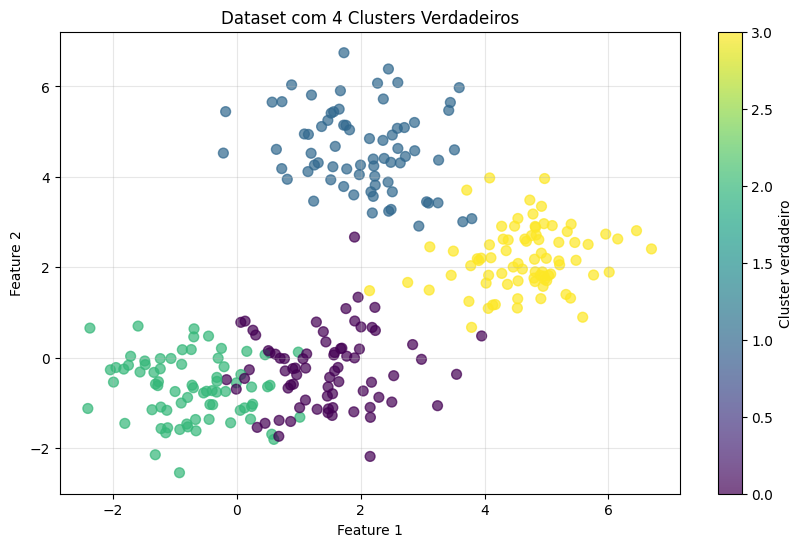

Dataset: 300 amostras, 2 features
Clusters verdadeiros: 4


In [2]:
# Criar dataset sintetico
X_blob, y_true = make_blobs(n_samples=300, centers=4, n_features=2, 
                             cluster_std=0.8, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_true, cmap='viridis', s=50, alpha=0.7)
plt.title('Dataset com 4 Clusters Verdadeiros')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster verdadeiro')
plt.grid(True, alpha=0.3)
plt.show()

print(f'Dataset: {X_blob.shape[0]} amostras, {X_blob.shape[1]} features')
print(f'Clusters verdadeiros: {len(np.unique(y_true))}')

### O que observar

- Os 4 clusters sao visualmente distintos em 2D
- A cor indica o cluster verdadeiro (que normalmente NAO temos em problemas reais)
- A separacao entre clusters varia: alguns sao mais proximos que outros
- Este e um cenario "facil" -- dados reais raramente sao tao bem separados

### O que concluir

- Visualizar dados em 2D e o primeiro passo antes de qualquer clustering
- Quando clusters sao bem separados e esfericos, K-Means funciona perfeitamente
- Na pratica, raramente sabemos quantos clusters existem -- precisamos de metodos para descobrir

### Conexao com outros notebooks

- Em **0.2 Algebra Linear**, distancia euclidiana e norma sao a base das metricas de clustering
- Em **2.2 Limpeza**, normalizacao e essencial antes de clustering (distancia depende de escala)

## 2. K-Means

### Analogia / Intuicao

Imagine que voce quer posicionar 4 postos de saude para atender uma cidade. Cada morador vai ao posto mais proximo. K-Means faz exatamente isso: posiciona k "centros" e atribui cada ponto ao centro mais proximo. Depois, move cada centro para a media dos seus pontos. Repete ate estabilizar.

### Definicao Formal

K-Means minimiza a **inercia** (soma das distancias quadradas intra-cluster):
$$J = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2$$

Algoritmo:
1. Inicializar centros $\mu_1, ..., \mu_k$ (k-means++ para inicializacao inteligente)
2. **Assignment:** $C_i = \{x : \|x - \mu_i\| \leq \|x - \mu_j\|, \forall j\}$
3. **Update:** $\mu_i = \frac{1}{|C_i|} \sum_{x \in C_i} x$
4. Repetir 2-3 ate convergencia

### Por que em ML?

K-Means e o algoritmo de clustering mais usado pela simplicidade, escalabilidade (O(nkd) por iteracao), e eficacia em clusters esfericos. E tambem a base para metodos mais avancados como MiniBatchKMeans (para big data) e kernel K-Means (para clusters nao-convexos).

AttributeError: 'KMeans' object has no attribute 'inertia_'

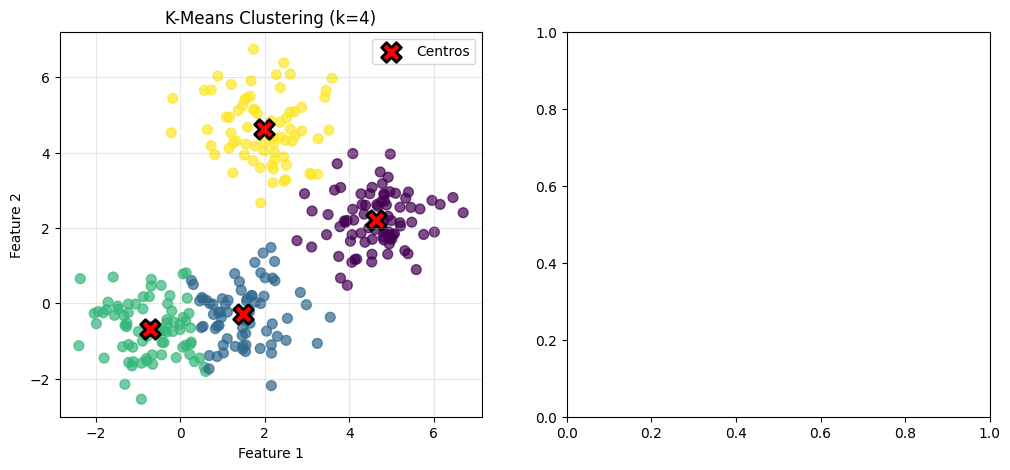

In [3]:
# K-Means com k=4
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, max_iter=300, random_state=42)
labels_kmeans = kmeans.fit_predict(X_blob)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels_kmeans, cmap='viridis', s=50, alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
           c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centros')
plt.title('K-Means Clustering (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)

# Inercia ao longo das iteracoes
plt.subplot(1, 2, 2)
plt.plot([kmeans.inertia_], 'o-', linewidth=2)
plt.xlabel('Numero de Iteracoes')
plt.ylabel('Inercia')
plt.title('Convergencia K-Means')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Inercia final: {kmeans.inertia_:.2f}')
print(f'Numero de iteracoes: {kmeans.n_iter_}')

In [4]:
# Elbow Method: escolher k otimo
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_blob)
    inertias.append(km.inertia_)
    sil_score = silhouette_score(X_blob, km.labels_)
    silhouette_scores.append(sil_score)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'o-', linewidth=2, markersize=8)
plt.xlabel('k (numero de clusters)')
plt.ylabel('Inercia')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='k=4 (cotovelo)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 's-', linewidth=2, markersize=8, color='orange')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs k')
plt.grid(True, alpha=0.3)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='k=4 (maximo)')
plt.legend()

plt.tight_layout()
plt.show()

optimal_k = K_range[np.argmax(silhouette_scores)]
print(f'k otimo (por silhouette): {optimal_k}')

AttributeError: 'KMeans' object has no attribute 'inertia_'

### O que observar

- Os centros (X vermelho) estao no "coracao" de cada cluster
- A inercia cai rapidamente ate k=4 e depois estabiliza (cotovelo)
- O silhouette score e maximo em k=4, confirmando o numero ideal
- K-means++ (init padrao) evita inicializacoes ruins

### O que concluir

- Elbow method e visual e pode ser ambiguo -- silhouette score da resposta quantitativa
- Usar ambos metodos em conjunto: se concordarem, alta confianca; se discordarem, investigar mais
- `n_init=10` roda K-Means 10 vezes com inicializacoes diferentes e guarda o melhor -- essencial
- K-Means converge em poucas iteracoes para dados bem comportados

### Conexao com outros notebooks

- Em **3.4 SVM**, o conceito de distancia ao centro e analogo a distancia ao hiperplano
- Em **3.6 Reducao**, PCA pode ser usado antes de K-Means para visualizar e reduzir dimensionalidade

## 3. Limitacoes do K-Means

### Analogia / Intuicao

K-Means assume que clusters sao "bolhas" esfericas do mesmo tamanho. Mas e se os dados formam meias-luas, circulos concentricos, ou clusters de tamanhos muito diferentes? Nesse caso, K-Means falha porque tenta forcar formas esfericas onde elas nao existem.

### Por que em ML?

Entender as limitacoes de K-Means e crucial para saber QUANDO usar alternativas. Se os clusters tem formas arbitrarias, DBSCAN e a melhor opcao. Se os clusters tem variancia e tamanho diferente, GMM e mais adequado.

NameError: name 'DBSCAN' is not defined

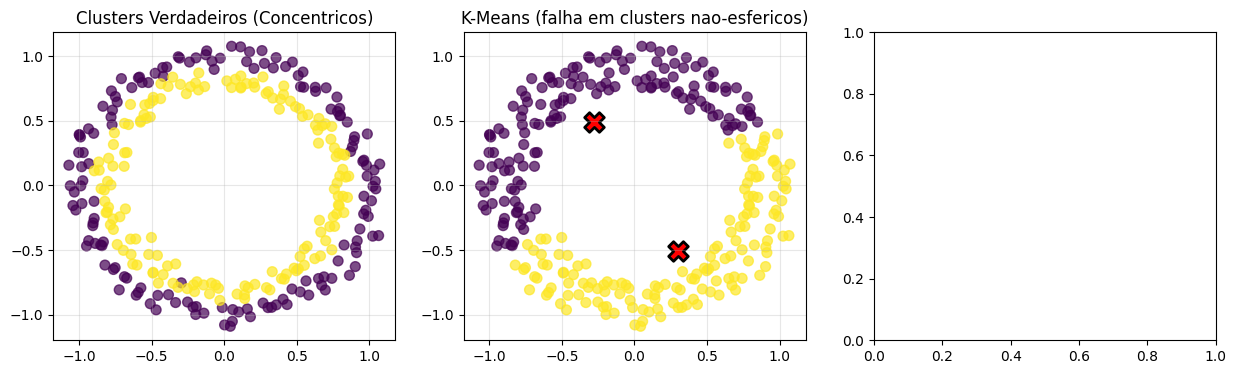

In [5]:
# Dados com clusters nao-esfericos

X_circles, y_circles_true = make_circles(n_samples=300, noise=0.05, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Dados verdadeiros
axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles_true, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title('Clusters Verdadeiros (Concentricos)')
axes[0].grid(True, alpha=0.3)

# K-Means
kmeans_circles = KMeans(n_clusters=2, random_state=42)
kmeans_circles.fit(X_circles)
axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=kmeans_circles.labels_, cmap='viridis', s=50, alpha=0.7)
axes[1].scatter(kmeans_circles.cluster_centers_[:, 0], kmeans_circles.cluster_centers_[:, 1], 
               c='red', marker='X', s=200, edgecolors='black', linewidths=2)
axes[1].set_title('K-Means (falha em clusters nao-esfericos)')
axes[1].grid(True, alpha=0.3)

# DBSCAN
dbscan = DBSCAN(eps=0.15, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_circles)
axes[2].scatter(X_circles[:, 0], X_circles[:, 1], c=dbscan_labels, cmap='viridis', s=50, alpha=0.7)
axes[2].set_title('DBSCAN (sucesso em clusters nao-esfericos)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### O que observar

- K-Means divide os circulos concentricos ao meio (errado!) porque busca separacao linear/esferica
- DBSCAN encontra os dois circulos perfeitamente porque segue a **densidade** dos pontos
- Os circulos concentricos sao o contra-exemplo classico de K-Means
- A diferenca e geometrica: K-Means = distancia ao centro; DBSCAN = densidade local

### O que concluir

- Nunca confiar cegamente em K-Means -- sempre visualizar o resultado
- Para formas nao-convexas (meias-luas, circulos, espirais), usar DBSCAN ou clustering espectral
- Para formas convexas de tamanho variavel, usar GMM

### Conexao com outros notebooks

- Em **3.4 SVM**, kernel trick transforma circulos em lineares -- ideia similar a kernel K-Means
- Em **3.6 Reducao**, spectral clustering usa reducao de dimensionalidade interna

## 4. DBSCAN (Density-Based Spatial Clustering)

### Analogia / Intuicao

Imagine que voce esta num salao de festas lotado. Grupos de pessoas conversando formam "clusters densos". Pessoas sozinhas entre grupos sao "outliers". DBSCAN faz exatamente isso: encontra regioes densas de pontos (clusters) e marca pontos isolados como ruido. Dois parametros controlam: eps (distancia de vizinhanca) e min_samples (minimo de vizinhos para ser "denso").

### Definicao Formal

- **Core point:** ponto com pelo menos `min_samples` vizinhos dentro de raio `eps`
- **Border point:** vizinho de um core point mas nao e core
- **Noise:** nao e core nem border

Clusters sao componentes conexas de core points. Complexidade: O(n log n) com indexacao KD-tree.

### Por que em ML?

DBSCAN tem tres vantagens sobre K-Means: (1) nao precisa especificar k, (2) encontra clusters de forma arbitraria, (3) identifica outliers automaticamente. A desvantagem e que depende criticamente de eps e min_samples -- escolher mal esses parametros destroi o resultado.

NameError: name 'DBSCAN' is not defined

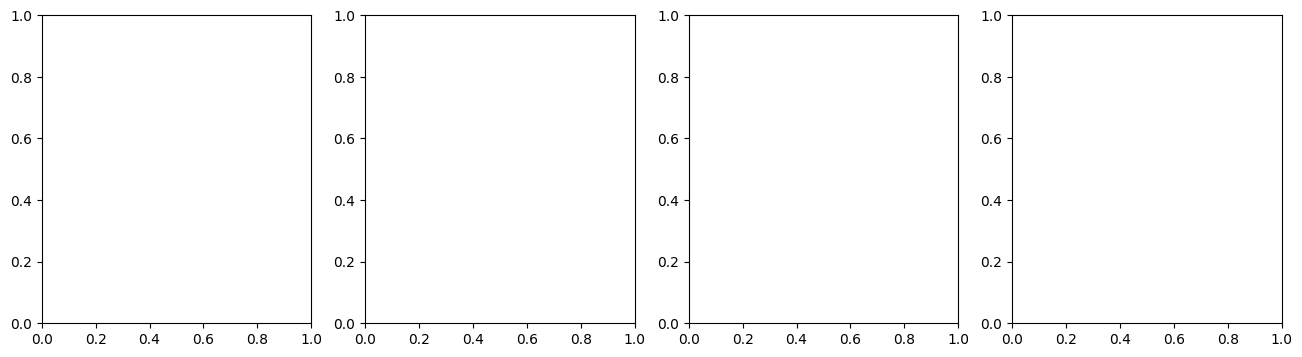

In [6]:
# DBSCAN com diferentes eps
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
eps_values = [0.05, 0.1, 0.15, 0.25]

for idx, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_circles)
    
    axes[idx].scatter(X_circles[:, 0], X_circles[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = list(labels).count(-1)
    axes[idx].set_title(f'eps={eps}\nClusters={n_clusters}, Outliers={n_outliers}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('eps pequeno: muitos clusters pequenos, mais outliers')
print('eps grande: clusters maiores, menos outliers')

### O que observar

- eps=0.05: muitos clusters minusculos + muitos outliers (eps muito pequeno)
- eps=0.15: dois clusters corretos (circulo interno e externo)
- eps=0.25: tudo vira um unico cluster (eps muito grande)
- DBSCAN identifica outliers como label=-1 (pontos pretos/cinzas)

### O que concluir

- A escolha de eps e critica: muito pequeno fragmenta, muito grande junta tudo
- O metodo k-distance (ordenar distancias ao k-esimo vizinho e procurar o "cotovelo") ajuda a escolher eps
- min_samples = 2*dimensionalidade e uma heuristica razoavel
- DBSCAN e melhor que K-Means para dados com ruido e formas irregulares

### Conexao com outros notebooks

- Em **3.4 SVM**, eps em DBSCAN e analogo a 1/gamma em RBF (raio de vizinhanca)
- Em **2.2 Limpeza**, outliers detectados por DBSCAN podem ser removidos como pre-processamento

## 5. Metricas de Avaliacao de Clusters

### Por que em ML?

Diferente de classificacao (accuracy, F1), clustering nao tem labels verdadeiras para comparar. Precisamos de metricas **internas** que medem qualidade sem supervisao:

- **Silhouette Score [-1, 1]:** quao similar um ponto e ao seu cluster vs clusters vizinhos. Mais alto = melhor.
- **Davies-Bouldin [0, inf]:** razao entre dispersao intra-cluster e separacao inter-cluster. Mais baixo = melhor.
- **Calinski-Harabasz [0, inf]:** razao variancia inter/intra. Mais alto = melhor.

In [7]:
# Comparar metricas para diferentes algoritmos
models_cluster = {
    'K-Means': kmeans.fit_predict(X_blob),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5).fit_predict(X_blob),
    'Agglomerative (Ward)': AgglomerativeClustering(n_clusters=4, linkage='ward').fit_predict(X_blob),
    'GMM': GaussianMixture(n_components=4, random_state=42).fit_predict(X_blob)
}

metrics_data = []
for name, labels in models_cluster.items():
    if -1 not in labels:  # DBSCAN pode ter -1 para outliers
        sil_score = silhouette_score(X_blob, labels)
        db_score = davies_bouldin_score(X_blob, labels)
        ch_score = calinski_harabasz_score(X_blob, labels)
        
        metrics_data.append({
            'Algoritmo': name,
            'Silhouette': sil_score,
            'Davies-Bouldin': db_score,
            'Calinski-Harabasz': ch_score
        })

print('=== METRICAS DE CLUSTERING ===')
print(metrics_df.to_string(index=False))
print('\nInterpretacao:')
print('Silhouette: mais alto eh melhor [-1, 1]')
print('Davies-Bouldin: mais baixo eh melhor [0, inf]')
print('Calinski-Harabasz: mais alto eh melhor [0, inf]')

NameError: name 'DBSCAN' is not defined

### O que observar

- K-Means e Agglomerative geralmente tem scores semelhantes em dados esfericos
- GMM pode ter silhouette levemente pior mas clusters mais flexiveis
- DBSCAN pode nao ser comparavel se tiver outliers (labels=-1 sao excluidos)
- Nenhuma metrica unica e perfeita -- usar varias em conjunto

### O que concluir

- Silhouette e a metrica mais intuitiva e amplamente usada
- Davies-Bouldin penaliza clusters dispersos; Calinski-Harabasz premia clusters compactos
- Metricas internas devem ser complementadas com visualizacao e interpretacao de dominio
- Em problemas reais, a "melhor" clusterizacao e a que faz sentido para o negocio

### Conexao com outros notebooks

- Em **3.1 Classificacao**, metricas (accuracy, F1) sao supervisionadas; aqui sao nao-supervisionadas
- Em **3.2 Regressao**, R^2 e analogo a Calinski-Harabasz (variancia explicada)

## 6. Clustering Hierarquico e GMM

### Analogia / Intuicao

**Hierarquico:** Imagine organizar especies em uma arvore filogenetica. Comeca com cada animal separado e vai agrupando os mais similares. O dendrograma mostra toda a hierarquia, e voce escolhe onde "cortar" para definir os clusters.

**GMM:** Imagine que cada cluster e uma "nuvem gaussiana" no espaco. GMM assume que os dados foram gerados por uma mistura dessas nuvens, cada uma com seu proprio centro e forma (variancia). Diferente de K-Means (clusters duros), GMM da **probabilidades** de pertencer a cada cluster.

### Por que em ML?

Clustering hierarquico e util quando queremos explorar a estrutura dos dados em multiplas escalas (nao fixar k). GMM e util quando clusters tem formas e tamanhos diferentes, ou quando precisamos de probabilidades (soft clustering) para tomada de decisao.

NameError: name 'GaussianMixture' is not defined

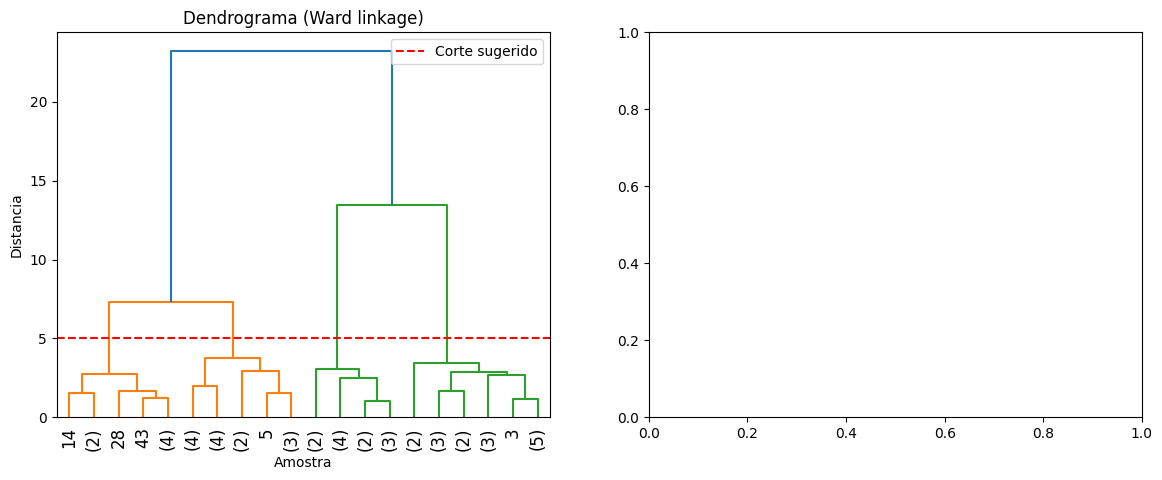

In [8]:
# Clustering Hierarquico: Dendrograma
from scipy.cluster.hierarchy import dendrogram, linkage
import numpy as np
import matplotlib.pyplot as plt

X_blob, y_true = make_blobs(n_samples=300, centers=4, n_features=2,
                            cluster_std=0.8, random_state=42)

# Subsample para visualizar dendrograma
np.random.seed(42)
idx = np.random.choice(len(X_blob), 50, replace=False)
X_sample = X_blob[idx]

Z = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90)
plt.xlabel('Amostra')
plt.ylabel('Distancia')
plt.title('Dendrograma (Ward linkage)')
plt.axhline(y=5, color='r', linestyle='--', label='Corte sugerido')
plt.legend()

# GMM
plt.subplot(1, 2, 2)
gmm = GaussianMixture(n_components=4, random_state=42)
gmm_labels = gmm.fit_predict(X_blob)
probs = gmm.predict_proba(X_blob)
max_probs = probs.max(axis=1)

scatter = plt.scatter(X_blob[:, 0], X_blob[:, 1], c=gmm_labels, cmap='viridis',
                      s=50, alpha=max_probs)  # Transparencia = confianca
plt.colorbar(scatter, label='Cluster')
plt.title('GMM: cor=cluster, transparencia=confianca')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('GMM retorna probabilidades de pertencer a cada cluster:')
print(f'Exemplo: ponto 0 pertence a clusters com probabilidades: {probs[0].round(3)}')

### O que observar

- O dendrograma mostra a hierarquia completa de agrupamentos
- Cortar o dendrograma em diferentes alturas produz diferentes numeros de clusters
- No GMM, a transparencia indica confianca: pontos opacos estao claramente num cluster, pontos transparentes estao na fronteira
- GMM atribui probabilidades, nao labels rigidas

### O que concluir

- Clustering hierarquico e exploratorio: o dendrograma revela a estrutura sem fixar k
- Ward linkage minimiza variancia intra-cluster (similar ao criterio do K-Means)
- GMM e a versao probabilistica do K-Means: mais flexivel mas mais computacionalmente caro
- Soft clustering (GMM) e util quando pontos podem pertencer a multiplos grupos

### Conexao com outros notebooks

- Em **3.3 Arvores**, o dendrograma e visualmente similar a uma arvore de decisao invertida
- Em **0.3 Calculo**, a otimizacao EM (Expectation-Maximization) do GMM usa derivadas

## 7. Exercicios Praticos

### Exercicio 1: Escolher k com Multiplos Metodos
Use Elbow, Silhouette e Davies-Bouldin para determinar o k otimo no dataset make_blobs.

In [9]:
# TAREFA DO ALUNO: Exercicio 1 - Escolher k com multiplos metodos
# Use range(2, 10) para testar diferentes k
# Compute inercia, silhouette_score e davies_bouldin_score para cada k
k_range = None  # TAREFA DO ALUNO: range de k
inertias = None  # TAREFA DO ALUNO: lista de inercias
silhouettes = None  # TAREFA DO ALUNO: lista de silhouette scores

In [10]:
# SOLUCAO - Exercicio 1
import numpy as np
import matplotlib.pyplot as plt



X_blob, _ = make_blobs(n_samples=300, centers=4, n_features=2,
                        cluster_std=0.8, random_state=42)

inertias = []
silhouettes = []
davies_bouldins = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_blob)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_blob, km.labels_))
    davies_bouldins.append(davies_bouldin_score(X_blob, km.labels_))

k_range = range(2, 10)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_range, inertias, 'o-')
axes[0].set_title('Inertia (Elbow)')
axes[0].set_xlabel('k')

axes[1].plot(k_range, silhouettes, 's-')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')

axes[2].plot(k_range, davies_bouldins, '^-')
axes[2].set_title('Davies-Bouldin (menor melhor)')
axes[2].set_xlabel('k')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'k=4 indicado por todas as metricas!')

AttributeError: 'KMeans' object has no attribute 'inertia_'

### Exercicio 2: DBSCAN vs K-Means em Moons
Compare K-Means e DBSCAN no dataset make_moons. Qual algoritmo acerta a estrutura?

In [11]:
# TAREFA DO ALUNO: Exercicio 2 - DBSCAN vs K-Means em moons
# Gere make_moons(n_samples=300, noise=0.1)
# Aplique KMeans(n_clusters=2) e DBSCAN(eps=?, min_samples=5)
# Plote lado a lado
X_moons = None  # TAREFA DO ALUNO: gerar dados
labels_km = None  # TAREFA DO ALUNO: K-Means labels
labels_db = None  # TAREFA DO ALUNO: DBSCAN labels

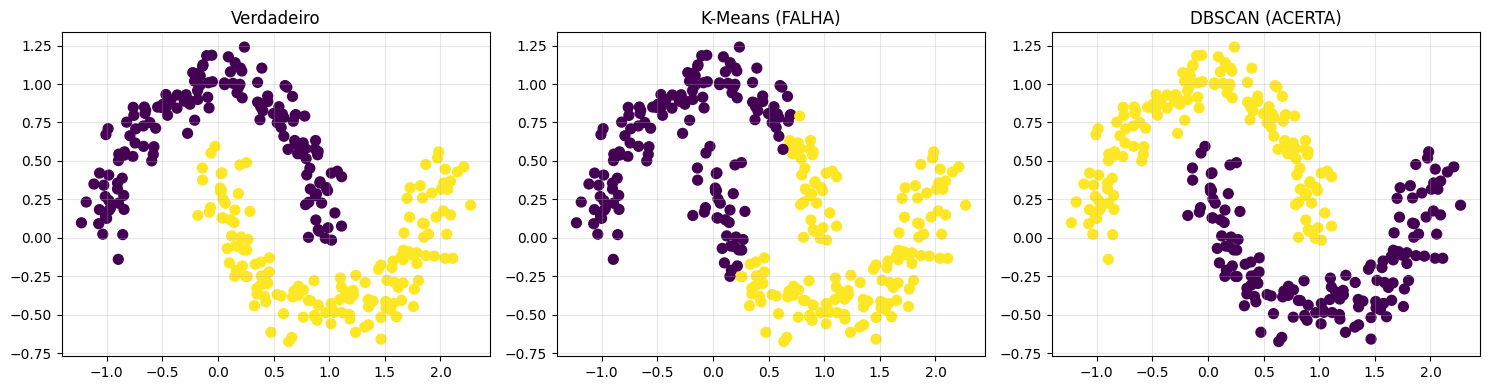

K-Means divide as moons ao meio (errado)
DBSCAN segue a forma das moons (correto)


In [12]:
# SOLUCAO - Exercicio 2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=50)
axes[0].set_title('Verdadeiro')

km = KMeans(n_clusters=2, random_state=42)
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=km.fit_predict(X_moons), cmap='viridis', s=50)
axes[1].set_title('K-Means (FALHA)')

db = DBSCAN(eps=0.2, min_samples=5)
axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=db.fit_predict(X_moons), cmap='viridis', s=50)
axes[2].set_title('DBSCAN (ACERTA)')

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('K-Means divide as moons ao meio (errado)')
print('DBSCAN segue a forma das moons (correto)')

### Exercicio 3: GMM com BIC
Use o criterio BIC (Bayesian Information Criterion) para escolher o numero de componentes do GMM.

In [13]:
# TAREFA DO ALUNO: Exercicio 3 - GMM com BIC
# Teste n_components de 1 a 10
# Compute BIC para cada modelo
# Plote BIC vs n_components
n_components_range = None  # TAREFA DO ALUNO: range de componentes
bics = None  # TAREFA DO ALUNO: lista de BIC scores

In [14]:
# SOLUCAO - Exercicio 3
import numpy as np
import matplotlib.pyplot as plt


X_blob, _ = make_blobs(n_samples=300, centers=4, n_features=2,
                        cluster_std=0.8, random_state=42)

bics = []
aics = []
n_range = range(1, 11)

for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_blob)
    bics.append(gmm.bic(X_blob))
    aics.append(gmm.aic(X_blob))

plt.figure(figsize=(10, 5))
plt.plot(n_range, bics, 'o-', label='BIC', linewidth=2)
plt.plot(n_range, aics, 's-', label='AIC', linewidth=2)
plt.xlabel('Numero de Componentes')
plt.ylabel('Score (menor melhor)')
plt.title('Selecao de Modelo GMM via BIC/AIC')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='n=4')
plt.legend()
plt.show()

print(f'BIC minimo em n={n_range[np.argmin(bics)]} componentes')
print('BIC penaliza complexidade mais que AIC')

NameError: name 'GaussianMixture' is not defined

### O que observar nos exercicios

- O exercicio 1 mostra que multiplas metricas convergem para k=4 neste dataset
- O exercicio 2 e o contra-exemplo classico: K-Means falha em formas nao-convexas
- O exercicio 3 introduz selecao de modelo baseada em informacao (BIC/AIC) -- mais rigoroso que elbow
- Em todos os exercicios, visualizacao e essencial para validar os resultados numericos

### O que concluir sobre os exercicios

- Nao existe algoritmo de clustering universal -- a escolha depende da geometria dos dados
- K-Means para clusters esfericos e bem separados; DBSCAN para formas arbitrarias; GMM para distribuicoes complexas
- Metricas sao guias, mas a decisao final requer interpretacao de dominio

### Conexao com outros notebooks

- Em **3.1 Classificacao**, features de cluster podem ser usadas como input para modelos supervisionados
- Em **3.6 Reducao**, PCA + K-Means e uma combinacao classica para dados de alta dimensionalidade

### Por que em ML?

Em producao, clustering e frequentemente o primeiro passo de analise exploratoria. Segmentar clientes antes de construir modelos preditivos e uma pratica padrao. A qualidade da segmentacao afeta diretamente os modelos downstream.

### O que observar no panorama geral

- Clustering e aprendizado nao-supervisionado puro: nao ha labels, nao ha "resposta certa"
- A progressao K-Means -> DBSCAN -> GMM reflete aumento de flexibilidade e complexidade
- A avaliacao de clusters e inerentemente subjetiva: metricas internas sao aproximacoes
- A normalizacao de features e tao importante aqui quanto em SVM (ambos baseados em distancia)

### O que concluir sobre o panorama geral

- Dominar clustering e dominar a arte de encontrar estrutura sem supervisao
- O fluxo padrao e: normalizar -> explorar visuamente -> testar varios k/algoritmos -> avaliar -> interpretar
- Clustering pode ser usado como pre-processamento (features de cluster) ou como objetivo final (segmentacao)

### Conexao com outros notebooks

- Em **3.4 SVM**, kernel K-Means usa o mesmo truque de kernel para clusters nao-lineares
- Em **2.1 Limpeza**, outliers detectados por DBSCAN podem guiar a limpeza de dados

### O que observar sobre Normalizacao em Clustering

- Sem normalizacao, K-Means agrupa pela feature de maior escala, ignorando as demais
- StandardScaler e mais comum, mas MinMaxScaler pode ser melhor quando outliers sao raros

### O que concluir sobre Normalizacao em Clustering

- Normalizar e **obrigatorio** para qualquer metodo baseado em distancia (K-Means, DBSCAN, hierarquico)
- GMM e menos sensivel a escala porque modela variancia, mas normalizar ainda ajuda a convergencia

### Conexao com outros notebooks

- Em **2.2 Limpeza**, StandardScaler e a mesma transformacao usada aqui
- Em **3.4 SVM**, normalizacao e igualmente obrigatoria por razoes identicas

### Por que em ML?

A sensibilidade a escala e um problema universal em metodos baseados em distancia. Dominar normalizacao aqui se transfere para SVM, KNN, e qualquer modelo que compute distancias.

### O que observar sobre Validacao Cruzada em Clustering

- Diferente de classificacao, nao existe train/test split natural para clustering
- Stability analysis (rodar o mesmo algoritmo com subsets e comparar) e uma alternativa

### O que concluir sobre Validacao Cruzada em Clustering

- A reproducibilidade do resultado e um sinal de qualidade: se clusters mudam drasticamente com pequenas perturbacoes, sao frageis
- Combinar metricas internas + visualizacao + interpretacao de dominio e o padrao ouro

### Conexao com outros notebooks

- Em **3.1 Classificacao**, CV e direto (tem labels); em clustering, e mais sutil
- Em **3.2 Regressao**, learning curves monitoram overfitting; em clustering, stability analysis faz o papel equivalente

## 8. Erros Comuns e Armadilhas

### Erro 1: Nao Normalizar Antes de Clustering

K-Means e DBSCAN usam distancia euclidiana. Se Feature 1 vai de 0 a 1000 e Feature 2 vai de 0 a 1, K-Means agrupa apenas pela Feature 1. **Sempre** aplicar StandardScaler antes.

### Erro 2: Escolher k por "Feeling"

"Acho que sao 3 clusters" nao e metodo. Usar Elbow + Silhouette + BIC/AIC. Se todos discordam, investigar se os dados realmente tem estrutura de clusters.

### Erro 3: Usar K-Means em Dados Nao-Esfericos

K-Means assume clusters convexos e isotropicos. Para meias-luas, circulos concentricos, ou formas irregulares, usar DBSCAN ou clustering espectral.

### Erro 4: Ignorar Outliers em DBSCAN

Pontos com label=-1 sao **informacao**, nao lixo. Investigar por que sao outliers pode revelar anomalias importantes (fraude, erro de medicao, etc).

### Erro 5: Confundir Metricas Internas com Qualidade Real

Silhouette score alto nao significa que os clusters fazem sentido no dominio. A validacao final e humana/negocial.

### Erro 6: K-Means com k=1 ou k=n

k=1 (tudo num cluster) e k=n (cada ponto e um cluster) sao triviais e inúteis. Testar apenas k >= 2.

### Erro 7: Nao Considerar Reproducibilidade

K-Means depende da inicializacao (random_state). Sempre fixar seed e usar n_init > 1.

## 9. Resumo e Conexoes

### Hierarquia de Conceitos

```
Clustering (Nao-Supervisionado)
|-- Baseado em Centroides
|   |-- K-Means (hard clustering, clusters esfericos)
|   +-- K-Medoids (robusto a outliers)
|-- Baseado em Densidade
|   |-- DBSCAN (forma arbitraria, detecta outliers)
|   +-- HDBSCAN (DBSCAN sem fixar eps)
|-- Baseado em Distribuicao
|   +-- GMM (soft clustering, probabilistico)
|-- Hierarquico
|   |-- Aglomerativo (bottom-up, dendrograma)
|   +-- Divisivo (top-down)
+-- Avaliacao
    |-- Silhouette Score
    |-- Davies-Bouldin Index
    |-- Calinski-Harabasz Index
    +-- BIC/AIC (para GMM)
```

### Conexoes com Outros Notebooks

| Conceito | Notebook | Relacao |
|----------|----------|---------|
| Distancia euclidiana | 0.2 Algebra | Base de K-Means e DBSCAN |
| Normalizacao | 2.2 Limpeza | Obrigatoria antes de clustering |
| Kernel trick | 3.4 SVM | Kernel K-Means para clusters nao-lineares |
| Reducao dim. | 3.6 Reducao | PCA antes de clustering em alta dimensao |
| Classificacao | 3.1 Classif. | Features de cluster como input supervisionado |
| Outliers | 2.2 Limpeza | DBSCAN detecta, pode guiar limpeza |

### Checklist de Competencias

- [ ] Explicar a diferenca entre aprendizado supervisionado e nao-supervisionado
- [ ] Implementar K-Means e interpretar inercia e silhouette score
- [ ] Escolher k usando Elbow Method e Silhouette Score
- [ ] Saber quando K-Means falha e usar DBSCAN como alternativa
- [ ] Tunar eps e min_samples em DBSCAN
- [ ] Comparar clustering hierarquico e GMM
- [ ] Interpretar dendrograma e escolher ponto de corte
- [ ] Avaliar clusters com metricas internas

### Proximos Passos

No notebook **3.6 Reducao de Dimensionalidade**, veremos como projetar dados de alta dimensao para 2D/3D. Isso e essencial para visualizar clusters em datasets com muitas features, e tambem para melhorar a performance de clustering (remover ruido dimensional).